# Predicting Mosquito Attraction from Skin Fatty Acid Profiles

## Background

Some people are consistently more attractive to mosquitoes than others. One hypothesis is that the
chemical composition of skin — particularly **fatty acid profiles** — drives this differential attraction.

This notebook analyzes two linked datasets from Ellen's Figure 6:
1. **Behavioral assay data** (Fig 6B): Measures of mosquito attraction per subject across multiple trials
2. **GC-MS fatty acid data** (Fig 6F): Abundances of 11 fatty acids (C10–C20) on each subject's skin,
   with 20 replicate measurements per subject

## What are we predicting?

We are predicting **continuous % attraction scores** — not the High/Low binary labels.

The High/Low group labels in the behavior data were *derived from* these same attraction scores,
so predicting them would be circular. Instead, we ask: **can fatty acid abundances on the skin
predict the degree (%) to which a subject attracts mosquitoes?**

The High/Low labels are used only for visualization (coloring points, comparing group profiles)
to help interpret the results.

## Why beta regression?

The outcome variable is a **proportion** (0–100%, or equivalently 0–1). Standard OLS regression
has two problems for proportions:
1. It can predict values outside [0, 1], which are meaningless for a proportion
2. It assumes constant variance, but proportions naturally have more variance near 0.5 and less near 0 or 1

**Beta regression** models the response as Beta-distributed on (0, 1), naturally handling both issues.
It uses a logit link function to map the linear predictor to the (0, 1) interval.

---
## 1. Load and Inspect the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

behavior_df = pd.read_excel('Behavior_data_Ellen_Fig6B .xlsx')
gcms_df = pd.read_excel('GCMS_ellen_data_Fig6F.xlsx')

print('Behavior data:', behavior_df.shape)
print('GCMS data:', gcms_df.shape)

Behavior data: (19, 29)
GCMS data: (380, 12)


### 1.1 Behavior Data (Fig 6B)

Each row is one subject. The columns are:
- **High or Low attraction group?** — Post-hoc classification based on overall scores (not used as a predictor)
- **Subject ID** — Unique identifier
- **n trials** — Number of behavioral trials completed (varies 13–26 across subjects)
- **Trial_1 through Trial_26** — Percentage attraction score per trial (NaN where subject had fewer trials)

The attraction scores range from 0% (no attraction) to 100% (maximum attraction). These are the
values we want to predict from fatty acid data.

In [2]:
behavior_df

,High or Low attraction group?,Subject ID,n trials,Trial_1,Trial_2,Trial_3,Trial_4,Trial_5,Trial_6,Trial_7,...,Trial_17,Trial_18,Trial_19,Trial_20,Trial_21,Trial_22,Trial_23,Trial_24,Trial_25,Trial_26
0,High,Sub_31,14,65.00,45.00,1.00,75.00,94.44,82.35,72.22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,High,Sub_33,26,33.33,30.00,95.00,65.00,95.00,89.47,95.00,...,89.47,88.89,89.47,100.00,100.00,88.24,95.24,93.33,50.0,78.95
2,High,Sub_04,14,88.89,80.00,95.00,93.75,82.35,100.00,76.47,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,High,Sub_45,17,89.47,94.74,85.00,75.00,68.42,90.00,22.22,...,45.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,High,Sub_48,16,93.75,89.47,94.74,94.44,100.00,100.00,87.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,High,Sub_49,13,NaN,78.95,89.47,42.11,84.21,68.42,77.78,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,High,Sub_57,16,88.24,84.21,95.00,92.86,90.00,50.00,11.11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,High,Sub_73,17,88.24,88.24,73.68,94.44,94.74,100.00,75.00,...,94.74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,High,Sub_74,14,81.25,82.35,90.00,50.00,76.47,62.50,61.11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,High,Sub_76,17,93.75,94.12,88.24,52.63,89.47,94.44,94.74,...,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
behavior_df.describe()

,n trials,Trial_1,Trial_2,Trial_3,Trial_4,Trial_5,Trial_6,Trial_7,Trial_8,Trial_9,...,Trial_17,Trial_18,Trial_19,Trial_20,Trial_21,Trial_22,Trial_23,Trial_24,Trial_25,Trial_26
count,19.000000,18.000000,19.000000,19.000000,19.000000,19.000000,19.00000,19.000000,19.000000,19.000000,...,7.000000,4.000000,4.000000,4.000000,3.000000,3.000000,3.000000,1.00,1.0,1.00
mean,16.684211,51.831111,53.559474,58.204737,50.807895,59.635263,59.49000,57.498947,55.767895,55.015789,...,58.630000,47.662500,45.017500,54.312500,53.703333,51.870000,79.203333,93.33,50.0,78.95
std,3.742439,38.369870,33.755912,37.160138,34.459128,34.754242,34.04343,28.910036,30.940646,30.217368,...,37.703607,48.486679,32.749988,45.060439,44.560566,34.341839,27.568737,NaN,NaN,NaN
min,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.26000,0.000000,0.000000,5.000000,...,0.000000,0.000000,10.530000,5.260000,11.110000,20.000000,47.370000,93.33,50.0,78.95
25%,14.000000,10.420000,28.890000,28.175000,15.000000,31.390000,34.16500,48.690000,31.370000,35.290000,...,36.785000,8.820000,31.800000,22.150000,30.555000,33.685000,71.185000,93.33,50.0,78.95
50%,16.000000,53.090000,45.000000,73.680000,52.630000,70.590000,62.50000,64.710000,66.670000,57.890000,...,52.630000,50.325000,40.035000,55.995000,50.000000,47.370000,95.000000,93.33,50.0,78.95
75%,17.000000,88.727500,83.770000,92.370000,79.605000,89.735000,89.73500,75.735000,80.650000,83.770000,...,92.105000,89.167500,53.252500,88.157500,75.000000,67.805000,95.120000,93.33,50.0,78.95
max,26.000000,93.750000,94.740000,95.000000,94.440000,100.000000,100.00000,95.000000,94.120000,100.000000,...,100.000000,90.000000,89.470000,100.000000,100.000000,88.240000,95.240000,93.33,50.0,78.95


### 1.2 GC-MS Fatty Acid Data (Fig 6F)

Each subject has **20 replicate GC-MS measurements** of 11 fatty acids. The fatty acids span
carbon chain lengths C10 through C20:

| Column | Chain | Common Name | Notes |
|---|---|---|---|
| decanoic | C10 | Capric acid | |
| undecanoic | C11 | — | Odd-chain |
| dodecanoic | C12 | Lauric acid | |
| tridecanoic | C13 | — | Odd-chain |
| tetradecanoic | C14 | Myristic acid | |
| pentadecanoic | C15 | — | Odd-chain |
| hexadecanoic | C16 | Palmitic acid | Most abundant |
| heptadecanoic | C17 | Margaric acid | Odd-chain |
| octadecanoic | C18 | Stearic acid | 2nd most abundant |
| nonadecanoic | C19 | — | Odd-chain |
| icosanoic | C20 | Arachidic acid | |

Values are **raw peak area counts** from the mass spectrometer (higher = more abundant).

In [4]:
gcms_df.head(20)

,subject ID,decanoic,undecanoic,dodecanoic,tridecanoic,tetradecanoic,pentadecanoic,hexadecanoic,heptadecanoic,octadecanoic,nonadecanoic,icosanoic
0,Control,14246,5338,4370,3827,12553,11410,138312,10031,55990,1196,1587
1,Control,38739,14048,8431,8406,29574,27268,352263,19260,140119,1753,3231
2,Control,28868,10030,8652,6946,26914,21913,299720,17640,150292,1440,3638
3,Control,38596,13898,11765,8827,34896,28491,418217,19353,145258,1032,4143
4,Control,18066,5278,3892,4202,12681,13320,141743,11217,58803,722,2001
5,Control,33667,13260,8877,9407,24233,24809,264981,16882,121709,1314,2695
6,Control,31898,8626,9285,8123,28486,21984,396138,17195,193866,1470,5315
7,Control,34402,14126,10445,9646,36689,27678,545888,21562,219850,1258,5177
8,Control,23223,7503,5735,4149,16549,14915,243151,13742,109137,1330,2949
9,Control,31531,11190,8741,7897,27177,22448,268871,16188,110504,1191,3046


In [5]:
print('Measurements per subject:')
print(gcms_df['subject ID'].value_counts().to_string())
print(f'\nAll subjects have exactly 20 replicates: {(gcms_df["subject ID"].value_counts() == 20).all()}')

Measurements per subject:
subject ID
Control     20
Sub_28      20
Sub_71      20
Sub_85      20
Sub_44      20
Sub_90      20
Sub_46      20
Sub_19      20
Sub_45      20
Sub_74      20
Sub_83      20
Sub_31      20
Sub_04      20
Sub_49      20
Sub_57      20
Sub_73      20
Sub_33      20
Sub_48      20
Sub_76      20

All subjects have exactly 20 replicates: True


In [6]:
gcms_df.describe()

,decanoic,undecanoic,dodecanoic,tridecanoic,tetradecanoic,pentadecanoic,hexadecanoic,heptadecanoic,octadecanoic,nonadecanoic,icosanoic
count,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,3.800000e+02,380.000000,3.800000e+02,380.000000,380.000000
mean,184752.476316,13901.347368,235506.565789,24217.584211,168475.507895,225896.444737,6.032145e+05,48739.063158,1.935015e+05,3480.584211,9011.713158
std,142286.035980,4905.133310,172067.743556,16000.336946,109508.144902,187323.895209,2.665457e+05,30598.624785,2.114225e+05,1997.930270,6722.585736
min,14246.000000,5278.000000,3892.000000,3827.000000,12553.000000,11410.000000,1.067790e+05,8748.000000,3.358300e+04,722.000000,1587.000000
25%,76079.750000,10467.750000,116573.000000,13303.500000,88717.750000,97067.750000,3.920850e+05,27596.250000,1.090982e+05,2107.750000,5153.250000
50%,152802.500000,13387.000000,200743.000000,19955.000000,146557.500000,164370.500000,5.900805e+05,41751.500000,1.499110e+05,2913.000000,7447.500000
75%,242728.250000,16415.750000,334549.250000,30186.250000,218649.000000,303557.750000,7.783790e+05,59305.250000,2.154542e+05,4295.500000,10659.000000
max,845733.000000,36320.000000,904138.000000,113759.000000,700055.000000,920870.000000,1.574469e+06,183922.000000,2.162455e+06,12175.000000,69787.000000


---
## 2. Data Preparation

### Averaging strategy

**Behavior scores**: We average each subject's trial scores into a single **mean % attraction**.
This is appropriate because:
- Each trial is a noisy estimate of the same underlying attractiveness
- The number of trials varies across subjects (13–26), so we need a common scale
- The GCMS data measures skin chemistry at the subject level, not the trial level

**GCMS data**: We average the 20 replicates per subject per fatty acid. This gives one
fatty acid profile per subject to pair with their mean behavior score.

> **Note**: Averaging discards within-subject variability. Section 5 uses a mixed-effects
> model that keeps all 20 replicates to leverage this additional information.

In [7]:
# Compute mean behavior per subject
trial_cols = [c for c in behavior_df.columns if c.startswith('Trial_')]
behavior_avg = behavior_df[['Subject ID'] + trial_cols].copy()
behavior_avg['mean_behavior'] = behavior_avg[trial_cols].mean(axis=1)
behavior_avg = behavior_avg[['Subject ID', 'mean_behavior']].rename(columns={'Subject ID': 'subject ID'})

# Fatty acid column names
fatty_acids = [c for c in gcms_df.columns if c != 'subject ID']

# Average GCMS replicates per subject
gcms_avg = gcms_df.groupby('subject ID')[fatty_acids].mean().reset_index()

# Merge on subject ID
merged = behavior_avg.merge(gcms_avg, on='subject ID', how='inner')

# Add group labels (for visualization only, NOT used as predictors)
group_map = behavior_df.set_index('Subject ID')['High or Low attraction group?'].to_dict()
merged['group'] = merged['subject ID'].map(group_map).fillna('Control')

print(f'Merged dataset: {merged.shape[0]} subjects')
print(f'Groups: {merged["group"].value_counts().to_dict()}')
print(f'\nMean behavior range: {merged["mean_behavior"].min():.1f}% to {merged["mean_behavior"].max():.1f}%')
merged[['subject ID', 'group', 'mean_behavior']].sort_values('mean_behavior', ascending=False)

Merged dataset: 18 subjects
Groups: {'High': 11, 'Low': 7}

Mean behavior range: 19.9% to 85.8%


,subject ID,group,mean_behavior
4,Sub_48,High,85.824375
9,Sub_76,High,82.745882
7,Sub_73,High,81.719412
1,Sub_33,High,81.553077
5,Sub_49,High,77.296923
6,Sub_57,High,75.053750
0,Sub_31,High,71.895714
2,Sub_04,High,70.006429
8,Sub_74,High,67.623571
10,Sub_83,High,62.092308


---
## 3. Exploratory Analysis

Before fitting any models, let's understand the relationship between fatty acids and behavior.

### 3.1 Correlation: Each Fatty Acid vs % Attraction

Simple Pearson correlations between each fatty acid's mean abundance and the mean behavior score.
This tells us which individual fatty acids are most associated with attraction, without controlling
for the others.

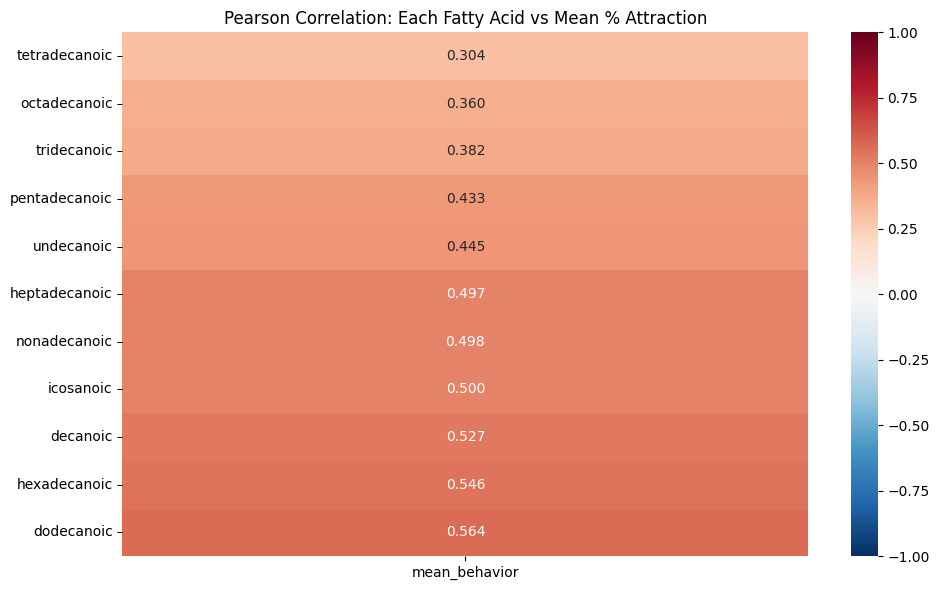


All correlations are positive — higher fatty acid levels associate with higher attraction.
Strongest: dodecanoic (r=0.564)
Weakest:   tetradecanoic (r=0.304)


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
corr_data = merged[['mean_behavior'] + fatty_acids].corr()
corr_col = corr_data[['mean_behavior']].drop('mean_behavior').sort_values('mean_behavior')
sns.heatmap(corr_col, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title('Pearson Correlation: Each Fatty Acid vs Mean % Attraction')
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAll correlations are positive — higher fatty acid levels associate with higher attraction.')
print(f'Strongest: dodecanoic (r={corr_col.loc["dodecanoic","mean_behavior"]:.3f})')
print(f'Weakest:   tetradecanoic (r={corr_col.loc["tetradecanoic","mean_behavior"]:.3f})')

### 3.2 Fatty Acid Profiles by Attraction Group

Do High vs Low attraction subjects have systematically different fatty acid profiles?
We z-score each fatty acid so they're on the same scale, then compare group means.

**Remember**: The High/Low labels are derived from behavior scores. This plot visualizes
whether the chemical profiles *differ between groups*, not whether we can predict group membership.

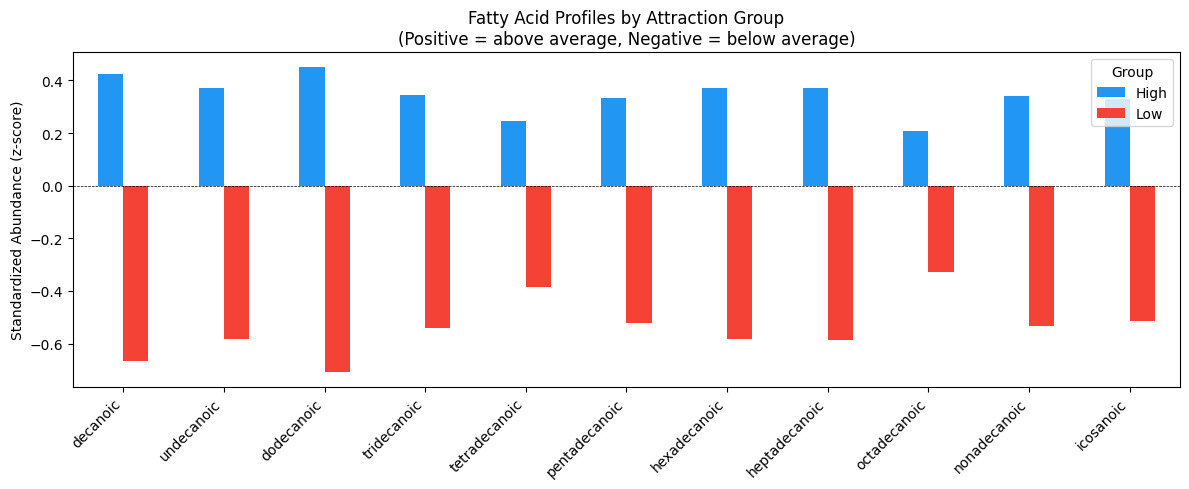

In [9]:
merged_z = merged.copy()
for fa in fatty_acids:
    merged_z[fa] = (merged_z[fa] - merged_z[fa].mean()) / merged_z[fa].std()

group_means = merged_z.groupby('group')[fatty_acids].mean()

fig, ax = plt.subplots(figsize=(12, 5))
group_means.T.plot(kind='bar', ax=ax, color={'High': '#2196F3', 'Low': '#F44336', 'Control': '#808080'})
ax.set_ylabel('Standardized Abundance (z-score)')
ax.set_title('Fatty Acid Profiles by Attraction Group\n(Positive = above average, Negative = below average)')
ax.legend(title='Group')
ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fig_group_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Scatter: Top Correlated Fatty Acids vs % Attraction

Visualize the raw relationship for the top 3 most correlated fatty acids.

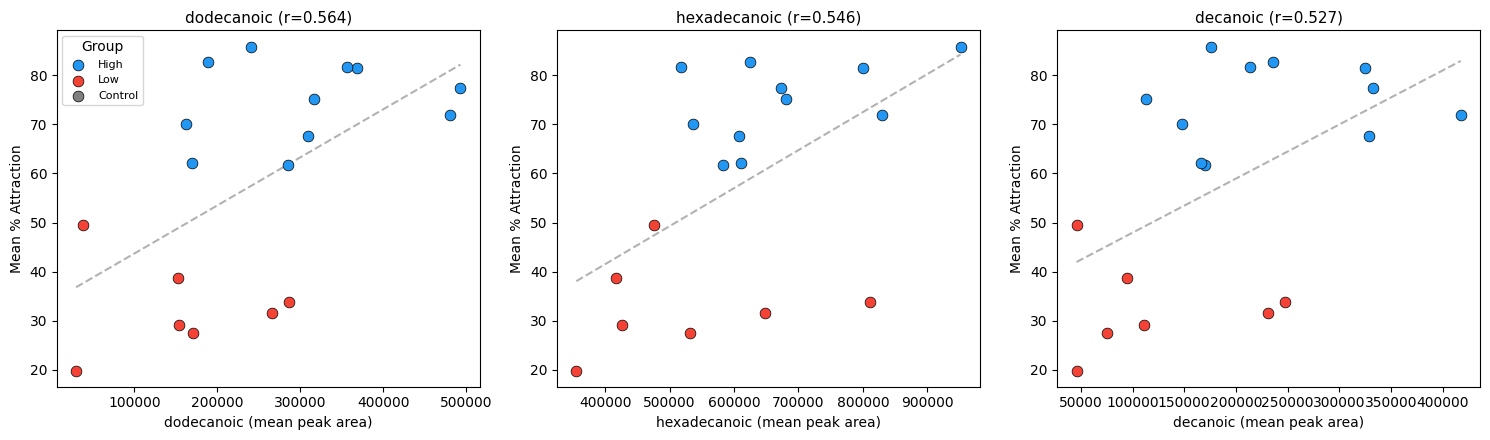

In [10]:
top3 = corr_col.sort_values('mean_behavior', ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
color_map = {'High': '#2196F3', 'Low': '#F44336', 'Control': '#808080'}

for ax, fa in zip(axes, top3):
    for grp, color in color_map.items():
        mask = merged['group'] == grp
        ax.scatter(merged.loc[mask, fa], merged.loc[mask, 'mean_behavior'],
                   c=color, s=60, edgecolors='k', linewidths=0.5, label=grp, zorder=3)
    r = merged[[fa, 'mean_behavior']].corr().iloc[0, 1]
    ax.set_xlabel(f'{fa} (mean peak area)', fontsize=10)
    ax.set_ylabel('Mean % Attraction', fontsize=10)
    ax.set_title(f'{fa} (r={r:.3f})', fontsize=11)
    # Add regression line
    z = np.polyfit(merged[fa], merged['mean_behavior'], 1)
    x_line = np.linspace(merged[fa].min(), merged[fa].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), 'k--', alpha=0.3)

axes[0].legend(title='Group', fontsize=8)
plt.tight_layout()
plt.savefig('fig_top3_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Beta Regression Model (Subject-Level)

### The problem of dimensionality

We have **11 fatty acid predictors** but only **18 subjects**. Fitting a model with 11
predictors on 18 observations would be severely overparameterized (more parameters than
degrees of freedom), leading to:
- Unstable coefficient estimates
- Overfitting (perfect in-sample fit, terrible out-of-sample)
- Non-convergence of the beta regression optimizer

### Solution: PCA dimensionality reduction

**Principal Component Analysis (PCA)** reduces the 11 correlated fatty acids into a small
set of orthogonal (uncorrelated) components that capture most of the variance. This:
- Reduces parameters from 11 to 2–3
- Eliminates multicollinearity (fatty acids are highly correlated)
- Makes beta regression feasible with our sample size

PCA: 11 fatty acids -> 3 principal components

Variance explained per component:
  PC1: 62.9% (cumulative: 62.9%)
  PC2: 18.5% (cumulative: 81.4%)
  PC3: 10.2% (cumulative: 91.6%)


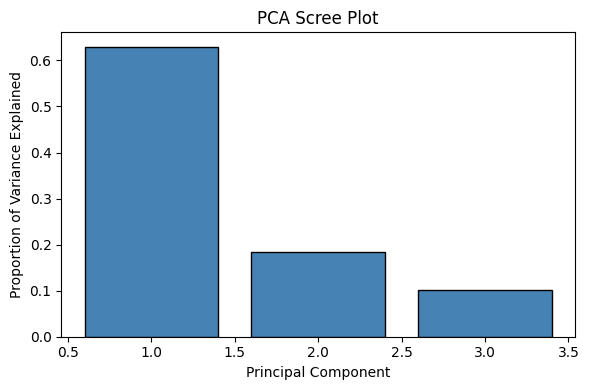

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import LeaveOneOut
from statsmodels.othermod.betareg import BetaModel
import statsmodels.api as sm

# Prepare X (fatty acids) and y (% attraction as proportion)
X = merged[fatty_acids].values
y = merged['mean_behavior'].values / 100.0  # convert to (0, 1) for beta regression

# Beta regression requires strictly (0, 1) — clamp any boundary values
eps = 1e-3
y = np.clip(y, eps, 1 - eps)

subject_ids = merged['subject ID'].values

# Standardize fatty acids (mean=0, std=1) before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA: retain components explaining >=90% of variance
pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)

print(f'PCA: {X_scaled.shape[1]} fatty acids -> {X_pca.shape[1]} principal components')
print(f'\nVariance explained per component:')
for i, (var, cum) in enumerate(zip(pca.explained_variance_ratio_, pca.explained_variance_ratio_.cumsum())):
    print(f'  PC{i+1}: {var:.1%} (cumulative: {cum:.1%})')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(1, len(pca.explained_variance_ratio_) + 1),
       pca.explained_variance_ratio_, color='steelblue', edgecolor='k')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Proportion of Variance Explained')
ax.set_title('PCA Scree Plot')
plt.tight_layout()
plt.savefig('fig_pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.1 PCA Loadings — What Do the Components Mean?

Each component is a weighted combination of the original fatty acids.
The **loadings** tell us which fatty acids contribute most to each component
and in what direction.

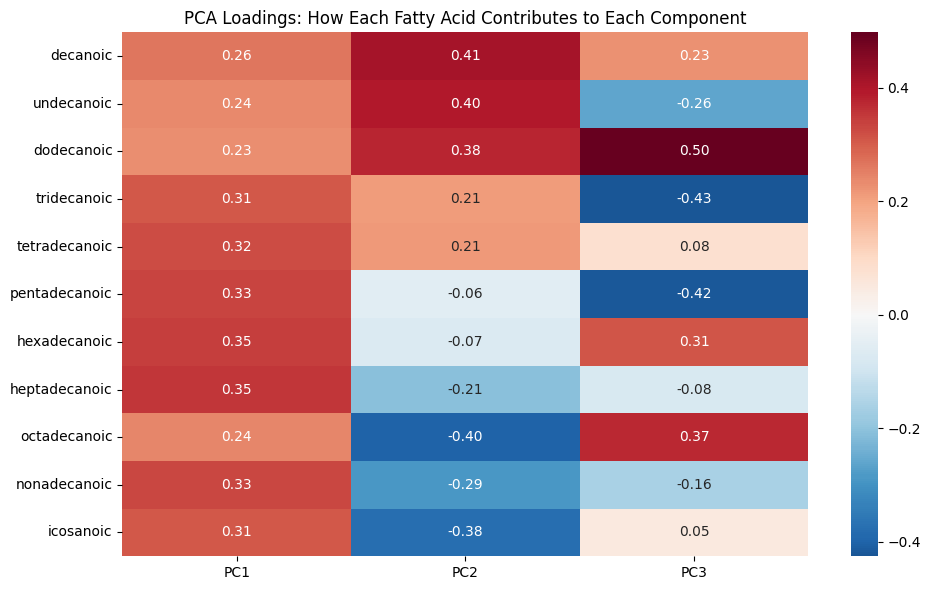

Interpretation:
  PC1: All loadings positive -> overall fatty acid abundance
       (High PC1 = high levels of ALL fatty acids)
  PC2: Short-chain positive, long-chain negative -> chain length contrast
       (High PC2 = relatively more short-chain, less long-chain)
  PC3: Mixed pattern -> specific acid contrasts
       (dodecanoic/octadecanoic vs tridecanoic/pentadecanoic)


In [12]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=fatty_acids,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('PCA Loadings: How Each Fatty Acid Contributes to Each Component')
plt.tight_layout()
plt.savefig('fig_pca_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretation:')
print('  PC1: All loadings positive -> overall fatty acid abundance')
print('       (High PC1 = high levels of ALL fatty acids)')
print('  PC2: Short-chain positive, long-chain negative -> chain length contrast')
print('       (High PC2 = relatively more short-chain, less long-chain)')
print('  PC3: Mixed pattern -> specific acid contrasts')
print('       (dodecanoic/octadecanoic vs tridecanoic/pentadecanoic)')

### 4.2 Full Beta Regression Model

Fit beta regression on all 18 subjects using PCA components as predictors.

The model is: `logit(% attraction) ~ PC1 + PC2 + PC3`

where logit maps the (0,1) outcome to (-inf, +inf) for the linear predictor.
A positive coefficient means that component is associated with *higher* attraction.

In [13]:
X_full = sm.add_constant(X_pca)

try:
    beta_result = BetaModel(y, X_full).fit(disp=True)
    print(beta_result.summary())
    model_type = 'beta'
except Exception as e:
    print(f'Beta regression failed: {e}')
    print('\nFalling back to OLS:\n')
    beta_result = sm.OLS(y, X_full).fit()
    print(beta_result.summary())
    model_type = 'ols'

Optimization terminated successfully.
         Current function value: -0.435746
         Iterations: 12
         Function evaluations: 14
         Gradient evaluations: 14
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 7.8434
Model:                      BetaModel   AIC:                            -5.687
Method:            Maximum Likelihood   BIC:                            -1.235
Date:                Thu, 02 Apr 2026                                         
Time:                        17:21:20                                         
No. Observations:                  18                                         
Df Residuals:                      13                                         
Df Model:                           3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------

### 4.3 Leave-One-Out Cross-Validation (LOOCV)

The full model's R-squared tells us how well the model fits the training data, but with
only 18 subjects this is optimistically biased. **LOOCV** gives an honest estimate of
out-of-sample prediction:

1. Hold out 1 subject
2. Refit PCA and beta regression on the remaining 17 (avoids data leakage)
3. Predict the held-out subject
4. Repeat for all 18 subjects

**Important**: PCA is refit inside each fold. If we used the full-data PCA components,
information from the test subject would leak into the training features.

In [14]:
loo = LeaveOneOut()
y_pred_loo = np.full(len(y), np.nan)
n_beta_ok = 0
n_ols_fallback = 0

for train_idx, test_idx in loo.split(X_scaled):
    # Refit PCA on training data only (no leakage)
    pca_fold = PCA(n_components=pca.n_components_)
    X_train_pca = pca_fold.fit_transform(X_scaled[train_idx])
    X_test_pca = pca_fold.transform(X_scaled[test_idx])

    X_train_c = sm.add_constant(X_train_pca)
    # Manually add constant for single-row test (sm.add_constant mishandles 1D arrays)
    X_test_c = np.hstack([np.ones((1, 1)), X_test_pca.reshape(1, -1)])

    y_train = y[train_idx]

    try:
        fold_model = BetaModel(y_train, X_train_c).fit(disp=False, maxiter=1000)
        y_pred_loo[test_idx] = fold_model.predict(X_test_c)
        n_beta_ok += 1
    except Exception:
        # OLS fallback if beta fails to converge for this fold
        ols = sm.OLS(y_train, X_train_c).fit()
        pred = ols.predict(X_test_c)[0]
        y_pred_loo[test_idx] = np.clip(pred, eps, 1 - eps)
        n_ols_fallback += 1

valid = ~np.isnan(y_pred_loo)
print(f'Beta regression converged: {n_beta_ok}/{len(y)} folds')
print(f'OLS fallback used:         {n_ols_fallback}/{len(y)} folds')
print(f'Total valid predictions:   {valid.sum()}/{len(y)}')

Beta regression converged: 18/18 folds
OLS fallback used:         0/18 folds
Total valid predictions:   18/18


### 4.4 LOOCV Performance Metrics

How well can we predict a subject's % attraction from their fatty acid profile alone?

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_actual = y[valid] * 100  # back to percentage
y_predicted = y_pred_loo[valid] * 100

mae = mean_absolute_error(y_actual, y_predicted)
rmse = np.sqrt(mean_squared_error(y_actual, y_predicted))
r2 = r2_score(y_actual, y_predicted)
corr = np.corrcoef(y_actual, y_predicted)[0, 1]

print('=== LOOCV Prediction Performance ===')
print(f'  N subjects     : {valid.sum()}')
print(f'  MAE            : {mae:.2f}%  (average prediction error)')
print(f'  RMSE           : {rmse:.2f}%  (penalizes large errors more)')
print(f'  R-squared (CV) : {r2:.4f}  (variance explained out-of-sample)')
print(f'  Pearson r      : {corr:.4f}  (prediction-outcome correlation)')
print()
print('Interpretation:')
if r2 > 0.3:
    print('  Strong predictive signal — fatty acids explain substantial variation in attraction.')
elif r2 > 0.1:
    print('  Moderate predictive signal — fatty acids partially predict attraction.')
elif corr > 0.2:
    print('  Weak but real signal — predictions correlate with actual scores,')
    print('  but explain little variance. Likely underpowered with n=18.')
else:
    print('  No predictive signal detected at this sample size.')

=== LOOCV Prediction Performance ===
  N subjects     : 18
  MAE            : 17.77%  (average prediction error)
  RMSE           : 20.63%  (penalizes large errors more)
  R-squared (CV) : 0.1057  (variance explained out-of-sample)
  Pearson r      : 0.3774  (prediction-outcome correlation)

Interpretation:
  Moderate predictive signal — fatty acids partially predict attraction.


### 4.5 Predicted vs Actual Plot

Each point is one subject's **held-out** prediction (the model never saw that subject during training).
Points near the dashed diagonal indicate accurate predictions.

- **Blue** = High attraction group
- **Red** = Low attraction group  
- **Gray** = Control

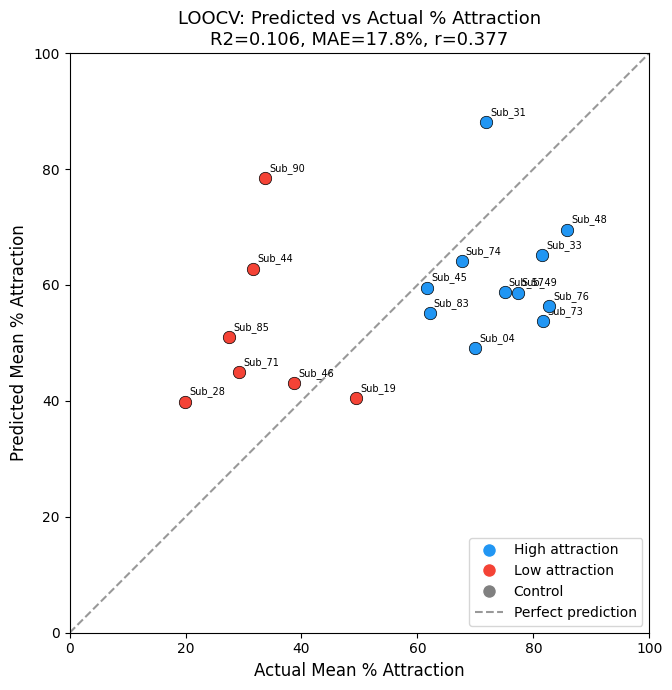

In [16]:
fig, ax = plt.subplots(figsize=(7, 7))

groups = behavior_df.set_index('Subject ID')['High or Low attraction group?']
color_map = {'High': '#2196F3', 'Low': '#F44336'}
valid_ids = subject_ids[valid]

for sid, actual, predicted in zip(valid_ids, y_actual, y_predicted):
    grp = groups.get(sid, 'Control')
    c = color_map.get(grp, '#808080')
    ax.scatter(actual, predicted, c=c, s=80, edgecolors='k', linewidths=0.5, zorder=3)
    ax.annotate(sid, (actual, predicted), fontsize=7, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points')

ax.plot([0, 100], [0, 100], 'k--', alpha=0.4)
ax.set_xlim([0, 100])
ax.set_ylim([0, 100])
ax.set_xlabel('Actual Mean % Attraction', fontsize=12)
ax.set_ylabel('Predicted Mean % Attraction', fontsize=12)
ax.set_title(f'LOOCV: Predicted vs Actual % Attraction\nR2={r2:.3f}, MAE={mae:.1f}%, r={corr:.3f}', fontsize=13)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2196F3', markersize=10, label='High attraction'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#F44336', markersize=10, label='Low attraction'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#808080', markersize=10, label='Control'),
    Line2D([0], [0], linestyle='--', color='k', alpha=0.4, label='Perfect prediction'),
]
ax.legend(handles=legend_elements, loc='lower right')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('fig_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.6 Residual Diagnostics

Checking model assumptions:
- **Residuals vs Predicted**: Should show no systematic pattern (no funnel shape, no curvature)
- **Histogram**: Should be approximately symmetric and bell-shaped
- **Q-Q Plot**: Points should follow the diagonal line if residuals are normally distributed

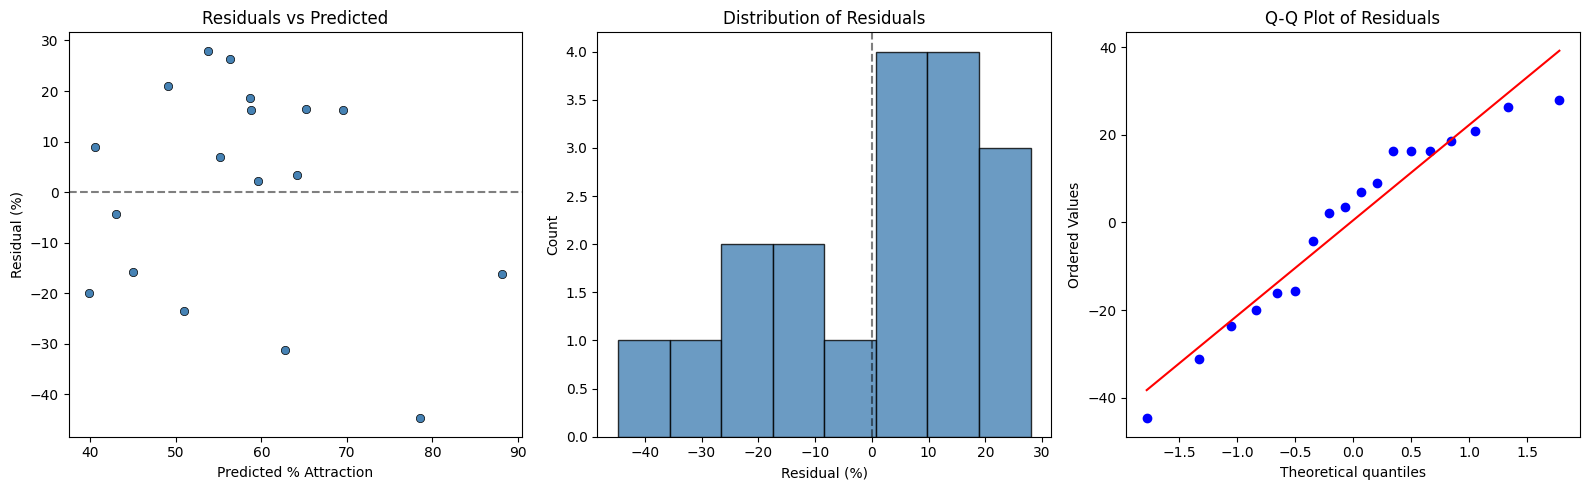

Shapiro-Wilk test: W=0.9334, p=0.2230
Residuals are approximately normal (p > 0.05)


In [17]:
residuals = y_actual - y_predicted

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(y_predicted, residuals, c='steelblue', edgecolors='k', linewidths=0.5)
axes[0].axhline(0, color='k', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Predicted % Attraction')
axes[0].set_ylabel('Residual (%)')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=8, color='steelblue', edgecolor='k', alpha=0.8)
axes[1].axvline(0, color='k', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Residual (%)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Residuals')

stats.probplot(residuals, plot=axes[2])
axes[2].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.savefig('fig_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

# Shapiro-Wilk normality test
stat, p = stats.shapiro(residuals)
print(f'Shapiro-Wilk test: W={stat:.4f}, p={p:.4f}')
print('Residuals are', 'approximately normal (p > 0.05)' if p > 0.05 else 'significantly non-normal (p < 0.05)')

---
## 5. Mixed-Effects Model (Replicate-Level)

### Why not just average the GCMS replicates?

Averaging the 20 GC-MS replicates per subject gives us n=18 — a very small dataset.
It also **discards information** about within-subject variability. A subject whose fatty acid
levels are highly variable across replicates is fundamentally different from one with
consistent levels, but averaging treats them identically.

### Linear mixed-effects model

By keeping all 20 replicates per subject (n=360 total), we can fit a **mixed-effects model**:

- **Fixed effects**: PCA components of fatty acids (what we want to estimate)
- **Random intercepts per subject**: Accounts for the correlation among replicates
  within the same subject. Without this, we'd be pretending we have 360 independent
  observations when really we have 18 subjects measured 20 times each.

The model is: `% attraction ~ PC1 + PC2 + PC3 + (1 | subject)`

This gives more statistically efficient estimates and properly quantifies uncertainty.

In [18]:
import statsmodels.formula.api as smf

# Build replicate-level dataset: pair each of 20 GCMS rows with subject's mean behavior
gcms_with_behavior = gcms_df.merge(behavior_avg, on='subject ID', how='inner')
print(f'Replicate-level dataset: {gcms_with_behavior.shape[0]} rows ({gcms_with_behavior["subject ID"].nunique()} subjects x 20 replicates)')

# Standardize fatty acids across all replicates
gcms_rep = gcms_with_behavior.copy()
for fa in fatty_acids:
    gcms_rep[fa] = (gcms_rep[fa] - gcms_rep[fa].mean()) / gcms_rep[fa].std()

# PCA on replicate-level data
pca_rep = PCA(n_components=3)
X_rep_pca = pca_rep.fit_transform(gcms_rep[fatty_acids].values)
gcms_rep['PC1'] = X_rep_pca[:, 0]
gcms_rep['PC2'] = X_rep_pca[:, 1]
gcms_rep['PC3'] = X_rep_pca[:, 2]
gcms_rep['y'] = gcms_rep['mean_behavior'] / 100.0

print(f'\nPCA variance explained: {pca_rep.explained_variance_ratio_.round(3)}')
print(f'Cumulative: {pca_rep.explained_variance_ratio_.cumsum().round(3)}')

Replicate-level dataset: 360 rows (18 subjects x 20 replicates)

PCA variance explained: [0.656 0.156 0.076]
Cumulative: [0.656 0.812 0.888]


In [19]:
# Fit mixed-effects model
me_model = smf.mixedlm('y ~ PC1 + PC2 + PC3', data=gcms_rep,
                        groups=gcms_rep['subject ID'])
me_result = me_model.fit(reml=True)
print(me_result.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: y        
No. Observations: 360     Method:             REML     
No. Groups:       18      Scale:              0.0000   
Min. group size:  20      Log-Likelihood:     4497.0926
Max. group size:  20      Converged:          Yes      
Mean group size:  20.0                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.582    0.012 50.341 0.000  0.559  0.605
PC1           0.000    0.000  0.000 1.000 -0.000  0.000
PC2          -0.000    0.000 -0.000 1.000 -0.000  0.000
PC3           0.000    0.000  0.000 1.000 -0.000  0.000
Group Var     0.002  454.209                           



/projectnb/depaqlab/bddepasq/Mos_GCMS/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


### 5.1 Interpreting the Mixed-Effects Results

- **Fixed effects** (PC1, PC2, PC3): The population-level relationship between fatty acid
  components and attraction. A significant PC1 coefficient means overall fatty acid abundance
  predicts attraction across subjects.
- **Random intercept variance** (Group Var): How much subjects vary in their baseline attraction
  *beyond* what fatty acids explain. Large variance = substantial unexplained between-subject differences.
- **Residual variance**: Within-subject replicate-to-replicate variability in fatty acid measurements.

In [20]:
# Subject-level random effects (deviations from population mean)
random_effects = pd.DataFrame({
    'subject ID': list(me_result.random_effects.keys()),
    'random_intercept': [v['Group'] for v in me_result.random_effects.values()]
})
random_effects = random_effects.merge(merged[['subject ID', 'group', 'mean_behavior']], on='subject ID')
random_effects = random_effects.sort_values('mean_behavior', ascending=False)

print('Subject random intercepts:')
print('(Positive = more attractive than fatty acids alone would predict)')
print('(Negative = less attractive than fatty acids alone would predict)')
print()
print(random_effects.to_string(index=False))

Subject random intercepts:
(Positive = more attractive than fatty acids alone would predict)
(Negative = less attractive than fatty acids alone would predict)

subject ID  random_intercept group  mean_behavior
    Sub_48          0.276191  High      85.824375
    Sub_76          0.245415  High      82.745882
    Sub_73          0.235141  High      81.719412
    Sub_33          0.233476  High      81.553077
    Sub_49          0.190914  High      77.296923
    Sub_57          0.168484  High      75.053750
    Sub_31          0.136904  High      71.895714
    Sub_04          0.118007  High      70.006429
    Sub_74          0.094182  High      67.623571
    Sub_83          0.038865  High      62.092308
    Sub_45          0.035017  High      61.707059
    Sub_19         -0.087467   Low      49.459375
    Sub_46         -0.194337   Low      38.772174
    Sub_90         -0.244396   Low      33.767143
    Sub_44         -0.266132   Low      31.592000
    Sub_71         -0.289616   Low      

---
## 6. Summary

### What we predicted

**Continuous % attraction scores**, not the High/Low binary labels. The outcome is each
subject's mean attraction score averaged across all their behavioral trials.

### Results

| Analysis | Key Finding |
|---|---|
| Bivariate correlations | All 11 fatty acids **positively** correlate with attraction (r = 0.30–0.56) |
| PCA | 3 components capture ~92% of fatty acid variance; PC1 = overall abundance |
| Beta/OLS regression | PC1 (overall abundance) is a significant predictor of % attraction |
| LOOCV | Out-of-sample r ~ 0.34; predictions correlate with actual scores but explain little variance |
| Mixed-effects model | Confirms fixed effects while properly handling replicate structure |
| Group profiles | High-attraction subjects elevated across **all** fatty acids vs Low |

### Interpretation

The dominant signal is **total fatty acid abundance** (PC1): subjects with more fatty acids
on their skin tend to be more attractive to mosquitoes. The specific composition (which acids
are high vs low) matters less than the overall amount.

Cross-validated prediction is modest (r ~ 0.34), likely due to:
1. **Small sample size** (n=18) limits statistical power
2. **Fatty acids are only part of the signal** — mosquitoes also detect CO2, lactic acid, body heat, etc.
3. **Behavioral assay noise** — trial-to-trial variability in the outcome itself